In [4]:
pip install gymnasium torch numpy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Hyperparameters
GAMMA = 0.99
LR = 3e-4
EPS_CLIP = 0.2
K_EPOCHS = 4
EPISODES = 1000

**Network**

In [6]:
class ActorCritic(nn.Module):

    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.fc1 = nn.Linear(state_dim, 128)

        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):

        x = F.relu(self.fc1(x))

        probs = F.softmax(self.actor(x), dim=-1)
        value = self.critic(x)

        return probs, value


def compute_returns(rewards):

    returns = []
    R = 0

    for r in reversed(rewards):
        R = r + GAMMA * R
        returns.insert(0, R)

    return torch.tensor(returns, dtype=torch.float32)
    

**Training loop**

In [7]:
def train():

    env = gym.make("CartPole-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    model = ActorCritic(state_dim, action_dim)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    rewards_per_episode = []

    for episode in range(EPISODES):

        states = []
        actions = []
        rewards = []
        log_probs = []
        values = []

        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:

            state_t = torch.FloatTensor(state)

            probs, value = model(state_t)

            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            states.append(state_t)
            actions.append(action)
            rewards.append(reward)
            log_probs.append(dist.log_prob(action))
            values.append(value)

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

        states = torch.stack(states)
        actions = torch.stack(actions)
        old_log_probs = torch.stack(log_probs).detach()
        values = torch.stack(values).squeeze()

        returns = compute_returns(rewards)

        advantages = returns - values.detach()

        for _ in range(K_EPOCHS):

            probs, value = model(states)

            dist = torch.distributions.Categorical(probs)
            new_log_probs = dist.log_prob(actions)

            ratio = torch.exp(new_log_probs - old_log_probs)

            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1-EPS_CLIP, 1+EPS_CLIP) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()

            critic_loss = (returns - value.squeeze()).pow(2).mean()

            loss = actor_loss + 0.5 * critic_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if episode % 100 == 0:
            print("Episode:", episode, "Reward:", total_reward)

    env.close()

    return rewards_per_episode
    

Episode: 0 Reward: 16.0
Episode: 100 Reward: 26.0
Episode: 200 Reward: 141.0
Episode: 300 Reward: 83.0
Episode: 400 Reward: 500.0
Episode: 500 Reward: 135.0
Episode: 600 Reward: 128.0
Episode: 700 Reward: 264.0
Episode: 800 Reward: 500.0
Episode: 900 Reward: 500.0


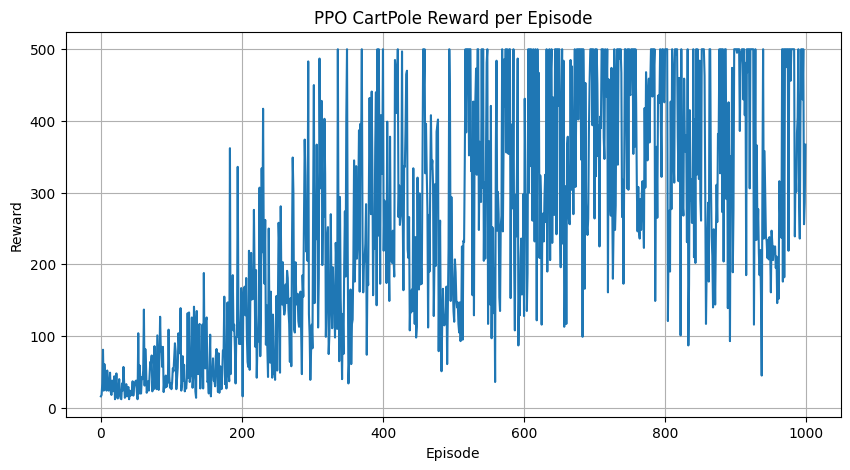

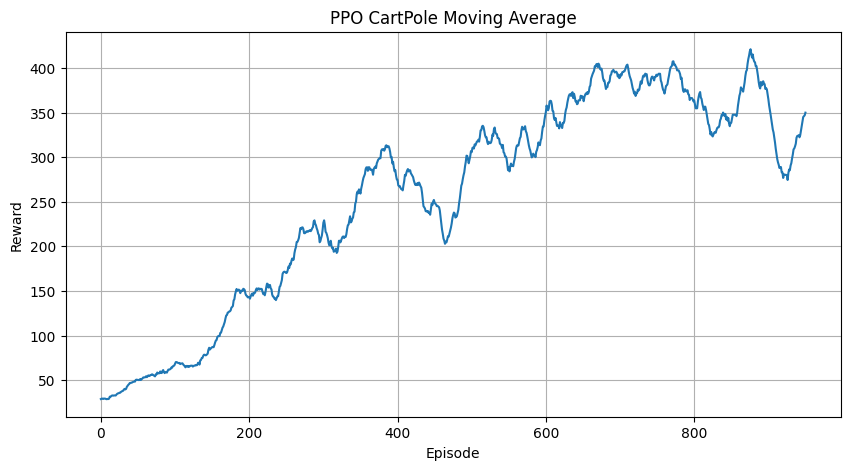

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rewards_per_episode = train()

smoothed = np.convolve(
    rewards_per_episode,
    np.ones(50)/50,
    mode='valid'
)

plt.figure(figsize=(10,5))
plt.plot(rewards_per_episode)
plt.title("PPO CartPole Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(smoothed)
plt.title("PPO CartPole Moving Average")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()
